In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib

In [2]:
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
FIGURES_DIR = Path("../reports/figures")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

churn_path = PROCESSED_DIR / "spotify_user_churn_clean.csv"

churn_df = pd.read_csv(churn_path)

In [3]:
segmentation_features = [
    "subscription_type",
    "country",
    "avg_daily_minutes",
    "number_of_playlists",
    "top_genre",
    "skips_per_day",
    "support_tickets",
    "days_since_last_login"
]

X_seg = churn_df[segmentation_features].copy()

X_seg.head()

,subscription_type,country,avg_daily_minutes,number_of_playlists,top_genre,skips_per_day,support_tickets,days_since_last_login
0,Premium,US,134.9,4,Electronic,6,0,1
1,Premium,PK,165.7,5,Pop,8,0,12
2,Free,DE,45.9,3,Classical,3,0,3
3,Premium,PK,106.0,0,Jazz,7,0,3
4,Premium,US,89.6,5,Country,2,1,6


In [4]:
numeric_features = [
    "avg_daily_minutes",
    "number_of_playlists",
    "skips_per_day",
    "support_tickets",
    "days_since_last_login"
]

categorical_features = [
    "subscription_type",
    "country",
    "top_genre"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    sparse_threshold=0
)

X_seg_processed = preprocessor.fit_transform(X_seg)

print("Processed segmentation data shape:", X_seg_processed.shape)

Processed segmentation data shape: (1000, 24)


In [5]:
inertias = []
silhouette_scores = []

k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_seg_processed)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_seg_processed, cluster_labels))

cluster_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

cluster_results

,k,inertia,silhouette_score
0,2,5938.269519,0.173309
1,3,5280.626290,0.178581
2,4,4829.277302,0.173907
3,5,4483.023838,0.144072
4,6,4271.048307,0.147617
5,7,4079.612908,0.121314
6,8,3922.334347,0.109866


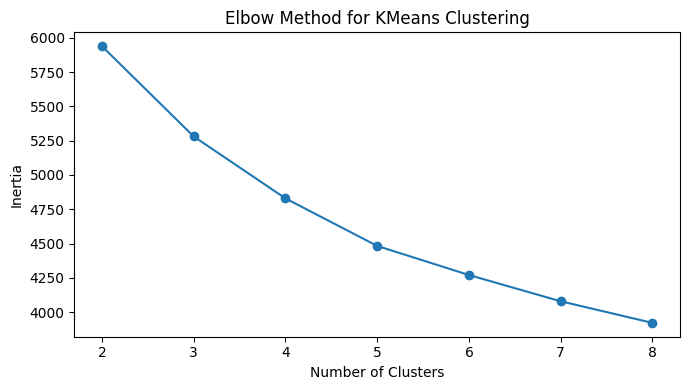

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(cluster_results["k"], cluster_results["inertia"], marker="o")
plt.title("Elbow Method for KMeans Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_elbow_curve.png", dpi=300)
plt.show()

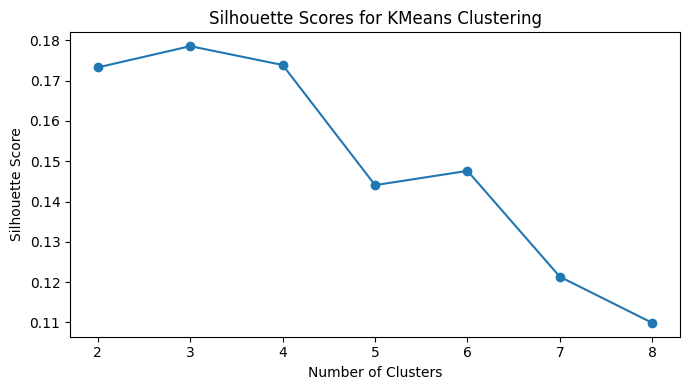

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(cluster_results["k"], cluster_results["silhouette_score"], marker="o")
plt.title("Silhouette Scores for KMeans Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_silhouette_scores.png", dpi=300)
plt.show()

In [8]:
final_k = 3

kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)

churn_df["user_segment"] = kmeans_final.fit_predict(X_seg_processed)

churn_df[["user_id", "user_segment"]].head()

,user_id,user_segment
0,user_1,0
1,user_2,0
2,user_3,1
3,user_4,1
4,user_5,2


In [9]:
segment_counts = churn_df["user_segment"].value_counts().sort_index()

segment_counts

user_segment
0    485
1    357
2    158
Name: count, dtype: int64

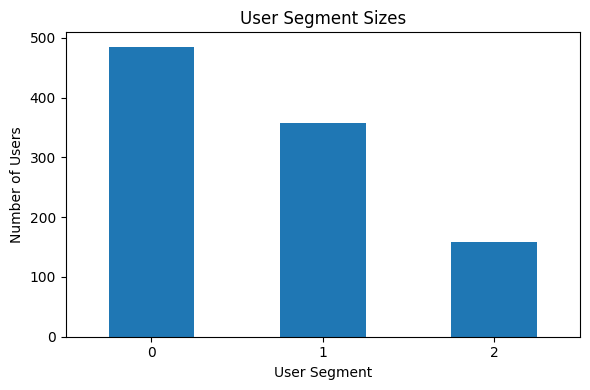

In [10]:
plt.figure(figsize=(6, 4))
segment_counts.plot(kind="bar")
plt.title("User Segment Sizes")
plt.xlabel("User Segment")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "user_segment_sizes.png", dpi=300)
plt.show()

In [11]:
segment_profile = churn_df.groupby("user_segment").agg({
    "avg_daily_minutes": "mean",
    "number_of_playlists": "mean",
    "skips_per_day": "mean",
    "support_tickets": "mean",
    "days_since_last_login": "mean",
    "churned": "mean",
    "user_id": "count"
}).rename(columns={
    "user_id": "user_count",
    "churned": "churn_rate"
})

segment_profile

,avg_daily_minutes,number_of_playlists,skips_per_day,support_tickets,days_since_last_login,churn_rate,user_count
user_segment,,,,,,,
0,122.326804,4.608247,4.711340,0.000000,9.418557,0.045361,485
1,59.722129,1.756303,4.526611,0.086835,9.795518,0.319328,357
2,111.446203,3.620253,4.620253,1.272152,9.056962,0.316456,158


## User Segment Interpretation
- Segment 0: Loyal High-Engagement Users
- Segment 1: Low-Engagement At-Risk Users
- Segment 2: High-Friction Engaged Users

In [12]:
subscription_by_segment = pd.crosstab(
    churn_df["user_segment"],
    churn_df["subscription_type"],
    normalize="index"
)

subscription_by_segment

subscription_type,Free,Premium
user_segment,,
0,0.010309,0.989691
1,0.955182,0.044818
2,0.234177,0.765823


In [13]:
genre_by_segment = pd.crosstab(
    churn_df["user_segment"],
    churn_df["top_genre"],
    normalize="index"
)

genre_by_segment

top_genre,Classical,Country,Electronic,Hip-Hop,Jazz,Pop,Rock
user_segment,,,,,,,
0,0.131959,0.154639,0.142268,0.146392,0.113402,0.144330,0.167010
1,0.165266,0.179272,0.151261,0.142857,0.142857,0.089636,0.128852
2,0.139241,0.151899,0.120253,0.196203,0.151899,0.113924,0.126582


In [14]:
segment_name_map = {
    0: "Segment 0",
    1: "Segment 1",
    2: "Segment 2",
    3: "Segment 3"
}

churn_df["segment_name"] = churn_df["user_segment"].map(segment_name_map)

churn_df[["user_id", "user_segment", "segment_name"]].head()

,user_id,user_segment,segment_name
0,user_1,0,Segment 0
1,user_2,0,Segment 0
2,user_3,1,Segment 1
3,user_4,1,Segment 1
4,user_5,2,Segment 2


In [15]:
segmented_users_path = PROCESSED_DIR / "spotify_users_segmented.csv"

churn_df.to_csv(segmented_users_path, index=False)

print("Saved segmented users to:", segmented_users_path)
print(churn_df.shape)

Saved segmented users to: ../data/processed/spotify_users_segmented.csv
(1000, 12)


In [16]:
segmentation_artifacts = {
    "preprocessor": preprocessor,
    "kmeans_model": kmeans_final,
    "segmentation_features": segmentation_features,
    "segment_name_map": segment_name_map
}

segmentation_model_path = MODELS_DIR / "user_segmentation_model.pkl"

joblib.dump(segmentation_artifacts, segmentation_model_path)

print("Saved segmentation model to:", segmentation_model_path)

Saved segmentation model to: ../models/user_segmentation_model.pkl


## Overall Segment Insight

The segmentation shows that churn risk comes from two different sources. Segment 1 churn is mainly caused by low engagement, while Segment 2 churn is more likely caused by user friction. Segment 0 shows that high engagement, playlist investment, and low friction are associated with very strong retention.

This is useful because it means Spotify should not use the same retention strategy for every user. Low-engagement users need reactivation and personalization, while high-friction engaged users need support intervention and issue resolution.